# Задание Light, выполненное с помощью Pytorch

1. Из ноутбуков по практике "Рекуррентные и одномерные сверточные нейронные сети" выберите лучшую сеть, либо создайте свою.
2. Запустите раздел "Подготовка"
3. Подготовьте датасет с параметрами `VOCAB_SIZE=20'000`, `WIN_SIZE=1000`, `WIN_HOP=100`, как в ноутбуке занятия, и обучите выбранную сеть. Параметры обучения можно взять из практического занятия. Для  всех обучаемых сетей в данной работе они должны быть одни и теже.
4. Поменяйте размер словаря tokenaizera (`VOCAB_SIZE`) на `5000`, `10000`, `40000`.  Пересоздайте датасеты, при этом оставьте `WIN_SIZE=1000`, `WIN_HOP=100`.
Обучите выбранную нейронку на этих датасетах.  Сделайте выводы об  изменении  точности распознавания авторов текстов. Результаты сведите в таблицу
5. Поменяйте длину отрезка текста и шаг окна разбиения текста на векторы  (`WIN_SIZE`, `WIN_HOP`) используя значения (`500`,`50`) и (`2000`,`200`). Пересоздайте датасеты, при этом оставьте `VOCAB_SIZE=20000`. Обучите выбранную нейронку на этих датасетах. Сделайте выводы об  изменении точности распознавания авторов текстов.

Результаты всей работы сведите в таблицу.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import copy
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from tensorflow.keras.preprocessing.text import Tokenizer
import torch.optim as optim
import os
from sklearn.metrics import accuracy_score

In [ ]:
import gdown
# Загрузим датасет из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

'writers.zip'

In [ ]:
# Распакуем архив в папку writers
!unzip -o writers.zip -d writers/

Archive:  writers.zip
  inflating: writers/(Клиффорд_Саймак) Обучающая_5 вместе.txt  
  inflating: writers/(Клиффорд_Саймак) Тестовая_2 вместе.txt  
  inflating: writers/(Макс Фрай) Обучающая_5 вместе.txt  
  inflating: writers/(Макс Фрай) Тестовая_2 вместе.txt  
  inflating: writers/(О. Генри) Обучающая_50 вместе.txt  
  inflating: writers/(О. Генри) Тестовая_20 вместе.txt  
  inflating: writers/(Рэй Брэдберри) Обучающая_22 вместе.txt  
  inflating: writers/(Рэй Брэдберри) Тестовая_8 вместе.txt  
  inflating: writers/(Стругацкие) Обучающая_5 вместе.txt  
  inflating: writers/(Стругацкие) Тестовая_2 вместе.txt  
  inflating: writers/(Булгаков) Обучающая_5 вместе.txt  
  inflating: writers/(Булгаков) Тестовая_2 вместе.txt  


In [ ]:
# Настройка констант для загрузки данных
FILE_DIR  = 'writers'                     # Папка с текстовыми файлами
SIG_TRAIN = 'обучающая'                   # Признак обучающей выборки в имени файла
SIG_TEST  = 'тестовая'                    # Признак тестовой выборки в имени файла

In [ ]:
# Подготовим пустые списки

CLASS_LIST = []  # Список классов
text_train = []  # Список для оучающей выборки
text_test = []   # Список для тестовой выборки

# Получим списка файлов в папке
file_list = os.listdir(FILE_DIR)

for file_name in file_list:
    # Выделяем имя класса и типа выборки из имени файла
    m = re.match('\((.+)\) (\S+)_', file_name)
    # Если выделение получилось, то файл обрабатываем
    if m:

        # Получим имя класса
        class_name = m[1]

        # Получим имя выборки
        subset_name = m[2].lower()

        # Проверим тип выборки
        is_train = SIG_TRAIN in subset_name
        is_test = SIG_TEST in subset_name

        # Если тип выборки обучающая либо тестовая - файл обрабатываем
        if is_train or is_test:

            # Добавляем новый класс, если его еще нет в списке
            if class_name not in CLASS_LIST:
                print(f'Добавление класса "{class_name}"')
                CLASS_LIST.append(class_name)

                # Инициализируем соответствующих классу строки текста
                text_train.append('')
                text_test.append('')

            # Найдем индекс класса для добавления содержимого файла в выборку
            cls = CLASS_LIST.index(class_name)
            print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}", {subset_name} выборка.')

            # Откроем файл на чтение
            with open(f'{FILE_DIR}/{file_name}', 'r') as f:

                # Загрузим содержимого файла в строку
                text = f.read()
            # Определим выборку, куда будет добавлено содержимое
            subset = text_train if is_train else text_test

            # Добавим текста к соответствующей выборке класса. Концы строк заменяются на пробел
            subset[cls] += ' ' + text.replace('\n', ' ')

Добавление класса "Макс Фрай"
Добавление файла "(Макс Фрай) Обучающая_5 вместе.txt" в класс "Макс Фрай", обучающая выборка.
Добавление класса "О. Генри"
Добавление файла "(О. Генри) Тестовая_20 вместе.txt" в класс "О. Генри", тестовая выборка.
Добавление класса "Клиффорд_Саймак"
Добавление файла "(Клиффорд_Саймак) Тестовая_2 вместе.txt" в класс "Клиффорд_Саймак", тестовая выборка.
Добавление класса "Булгаков"
Добавление файла "(Булгаков) Тестовая_2 вместе.txt" в класс "Булгаков", тестовая выборка.
Добавление файла "(О. Генри) Обучающая_50 вместе.txt" в класс "О. Генри", обучающая выборка.
Добавление класса "Стругацкие"
Добавление файла "(Стругацкие) Тестовая_2 вместе.txt" в класс "Стругацкие", тестовая выборка.
Добавление файла "(Клиффорд_Саймак) Обучающая_5 вместе.txt" в класс "Клиффорд_Саймак", обучающая выборка.
Добавление класса "Рэй Брэдберри"
Добавление файла "(Рэй Брэдберри) Обучающая_22 вместе.txt" в класс "Рэй Брэдберри", обучающая выборка.
Добавление файла "(Булгаков) Обучающ

<>:12: SyntaxWarning: invalid escape sequence '\('
<>:12: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_2872/2214232407.py:12: SyntaxWarning: invalid escape sequence '\('
  m = re.match('\((.+)\) (\S+)_', file_name)


In [ ]:
# фиксация случайности
SEED = 42

np.random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda')

CLASS_COUNT = len(CLASS_LIST)

results = []

def split_sequence(seq, win, hop):
    return [
        seq[i:i + win]
        for i in range(0, len(seq) - win + 1, hop)
        if len(seq[i:i + win]) == win
    ]


def prepare_data(vocab_size, win_size, hop):
    tokenizer = Tokenizer(num_words=vocab_size, lower=True, oov_token='неизвестное_слово')

    tokenizer.fit_on_texts(text_train)

    train_seq = tokenizer.texts_to_sequences(text_train)
    test_seq = tokenizer.texts_to_sequences(text_test)

    x_train, y_train = [], []
    x_val, y_val = [], []

    for cls, seq in enumerate(train_seq):
        chunks = split_sequence(seq, win_size, hop)
        x_train.extend(chunks)
        y_train.extend([cls] * len(chunks))

    for cls, seq in enumerate(test_seq):
        chunks = split_sequence(seq, win_size, hop)
        x_val.extend(chunks)
        y_val.extend([cls] * len(chunks))

    print('x_train:', np.array(x_train).shape)
    print('y_train:', np.array(y_train).shape)
    print('x_val:', np.array(x_val).shape)
    print('y_val:', np.array(y_val).shape)

    return np.array(x_train), np.array(y_train), np.array(x_val), np.array(y_val)

class WriterModel(nn.Module):
    def __init__(self, vocab_size, class_count, embed_dim=64, hidden_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size + 1, embed_dim)

        self.spatial_dropout = nn.Dropout2d(0.3)

        self.gru = nn.GRU(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True, bidirectional=True)

        self.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(hidden_dim * 2, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, class_count))

    def forward(self, x):
        x = self.embedding(x)

        x = x.permute(0, 2, 1).unsqueeze(-1)
        x = self.spatial_dropout(x)
        x = x.squeeze(-1).permute(0, 2, 1)

        out, _ = self.gru(x)

        x, _ = torch.max(out, dim=1)

        x = self.fc(x)

        return x

def train_model(model, train_loader, val_loader):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.RMSprop(model.parameters(), lr=1e-3, alpha=0.9)

    history = {
        'loss': [],
        'accuracy': [],
        'val_loss': [],
        'val_accuracy': []
    }

    best_acc = 0
    best_state = None

    patience = 3
    patience_counter = 0

    for epoch in range(30):
        model.train()

        train_loss = 0
        train_preds = []
        train_true = []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()

            preds = model(xb)
            loss = criterion(preds, yb)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_preds.extend(torch.argmax(preds, dim=1).detach().cpu().numpy())
            train_true.extend(yb.detach().cpu().numpy())

        train_loss = train_loss / len(train_loader)
        train_acc = accuracy_score(train_true, train_preds)

        model.eval()

        val_loss = 0
        val_preds = []
        val_true = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)

                preds = model(xb)
                loss = criterion(preds, yb)

                val_loss += loss.item()
                val_preds.extend(torch.argmax(preds, dim=1).detach().cpu().numpy())
                val_true.extend(yb.detach().cpu().numpy())

        val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(val_true, val_preds)

        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        print(
            f'Эпоха {epoch + 1}/30 '
            f'Ошибка: {train_loss:.4f} '
            f'Точность: {train_acc:.4f} '
            f'Проверка: {val_acc:.4f}'
        )

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)

    return history, best_acc

def show_graph(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history['accuracy'], label='Обучающая выборка')
    plt.plot(history['val_accuracy'], label='Проверочная выборка')
    plt.xlabel('Эпоха')
    plt.ylabel('Точность')
    plt.title('График точности')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history['loss'], label='Обучающая выборка')
    plt.plot(history['val_loss'], label='Проверочная выборка')
    plt.xlabel('Эпоха')
    plt.ylabel('Ошибка')
    plt.title('График ошибки')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def run_experiment(vocab_size, win_size, hop):
    x_train, y_train, x_val, y_val = prepare_data(vocab_size, win_size, hop)

    x_train = torch.LongTensor(x_train)
    y_train = torch.LongTensor(y_train)

    x_val = torch.LongTensor(x_val)
    y_val = torch.LongTensor(y_val)

    g = torch.Generator()
    g.manual_seed(SEED)

    train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True, generator=g)

    val_loader = DataLoader(TensorDataset(x_val, y_val), batch_size=32, shuffle=False)

    model = WriterModel(vocab_size=vocab_size, class_count=CLASS_COUNT, embed_dim=64, hidden_dim=128).to(device)

    history, best_acc = train_model(model, train_loader, val_loader)

    return model, history, best_acc

def add_result(exp_num, vocab_size, win_size, hop, history):
    results.append({
        'Эксперимент': exp_num,
        'VOCAB_SIZE': vocab_size,
        'WIN_SIZE': win_size,
        'WIN_HOP': hop,
        'Количество эпох': len(history['loss']),
        'Точность на обучении': history['accuracy'][-1],
        'Точность на проверке': history['val_accuracy'][-1],
        'Лучшая точность на проверке': max(history['val_accuracy']),
        'Ошибка на обучении': history['loss'][-1],
        'Ошибка на проверке': history['val_loss'][-1],
        'Лучшая ошибка на проверке': min(history['val_loss'])
    })

    results_df = pd.DataFrame(results)

    return results_df

x_train: (18417, 1000)
y_train: (18417,)
x_val: (6968, 1000)
y_val: (6968,)
Эпоха 1/30 Ошибка: 1.3467 Точность: 0.4369 Проверка: 0.5406
Эпоха 2/30 Ошибка: 0.6137 Точность: 0.7679 Проверка: 0.6982
Эпоха 3/30 Ошибка: 0.2763 Точность: 0.9062 Проверка: 0.7312
Эпоха 4/30 Ошибка: 0.1226 Точность: 0.9601 Проверка: 0.6914
Эпоха 5/30 Ошибка: 0.0701 Точность: 0.9781 Проверка: 0.7392
Эпоха 6/30 Ошибка: 0.0449 Точность: 0.9861 Проверка: 0.7550
Эпоха 7/30 Ошибка: 0.0320 Точность: 0.9905 Проверка: 0.7058
Эпоха 8/30 Ошибка: 0.0300 Точность: 0.9911 Проверка: 0.6831
Эпоха 9/30 Ошибка: 0.0167 Точность: 0.9947 Проверка: 0.7104
Ранняя остановка


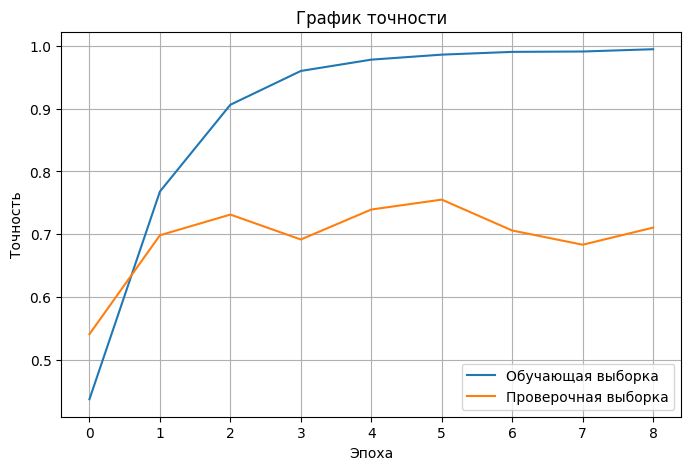

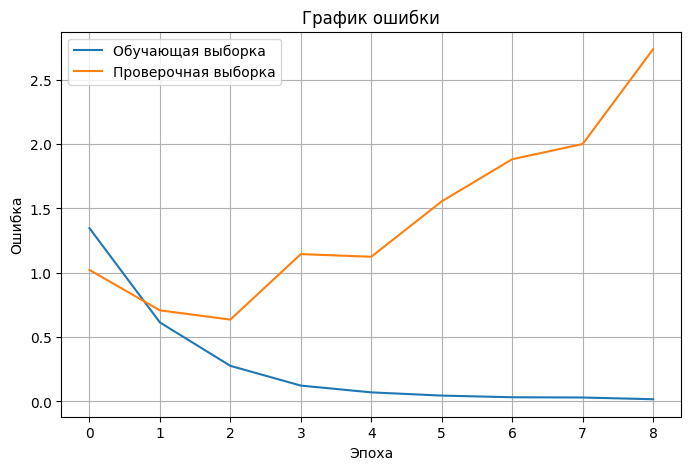

In [ ]:
VOCAB_SIZE = 20000
WIN_SIZE = 1000
WIN_HOP = 100

model_1, history_1, best_acc_1 = run_experiment(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

show_graph(history_1)

results_df = add_result(1, VOCAB_SIZE, WIN_SIZE, WIN_HOP, history_1)

x_train: (18417, 1000)
y_train: (18417,)
x_val: (6968, 1000)
y_val: (6968,)
Эпоха 1/30 Ошибка: 1.2021 Точность: 0.5149 Проверка: 0.6449
Эпоха 2/30 Ошибка: 0.4768 Точность: 0.8242 Проверка: 0.6719
Эпоха 3/30 Ошибка: 0.2134 Точность: 0.9261 Проверка: 0.7075
Эпоха 4/30 Ошибка: 0.1207 Точность: 0.9604 Проверка: 0.7226
Эпоха 5/30 Ошибка: 0.0690 Точность: 0.9784 Проверка: 0.7668
Эпоха 6/30 Ошибка: 0.0474 Точность: 0.9858 Проверка: 0.7282
Эпоха 7/30 Ошибка: 0.0391 Точность: 0.9900 Проверка: 0.7579
Эпоха 8/30 Ошибка: 0.0283 Точность: 0.9925 Проверка: 0.7722
Эпоха 9/30 Ошибка: 0.0239 Точность: 0.9932 Проверка: 0.7481
Эпоха 10/30 Ошибка: 0.0199 Точность: 0.9957 Проверка: 0.7745
Эпоха 11/30 Ошибка: 0.0219 Точность: 0.9950 Проверка: 0.7385
Эпоха 12/30 Ошибка: 0.0172 Точность: 0.9959 Проверка: 0.7658
Эпоха 13/30 Ошибка: 0.0137 Точность: 0.9970 Проверка: 0.7481
Ранняя остановка


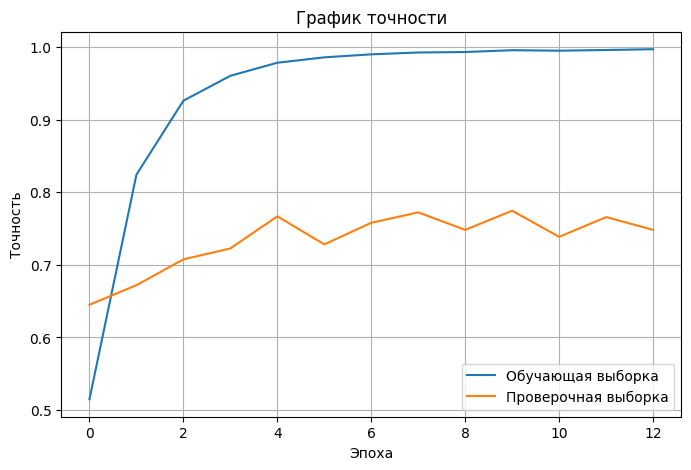

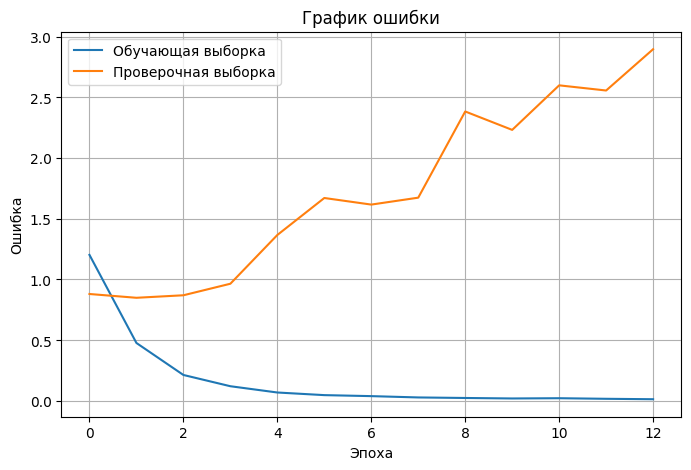

In [ ]:
VOCAB_SIZE = 5000
WIN_SIZE = 1000
WIN_HOP = 100

model_2, history_2, best_acc_2 = run_experiment(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

show_graph(history_2)

results_df = add_result(2, VOCAB_SIZE, WIN_SIZE, WIN_HOP, history_2)

x_train: (18417, 1000)
y_train: (18417,)
x_val: (6968, 1000)
y_val: (6968,)
Эпоха 1/30 Ошибка: 1.2262 Точность: 0.4982 Проверка: 0.6137
Эпоха 2/30 Ошибка: 0.4922 Точность: 0.8142 Проверка: 0.6678
Эпоха 3/30 Ошибка: 0.2358 Точность: 0.9172 Проверка: 0.6939
Эпоха 4/30 Ошибка: 0.1181 Точность: 0.9622 Проверка: 0.7787
Эпоха 5/30 Ошибка: 0.0667 Точность: 0.9790 Проверка: 0.7372
Эпоха 6/30 Ошибка: 0.0483 Точность: 0.9860 Проверка: 0.7187
Эпоха 7/30 Ошибка: 0.0333 Точность: 0.9908 Проверка: 0.7616
Ранняя остановка


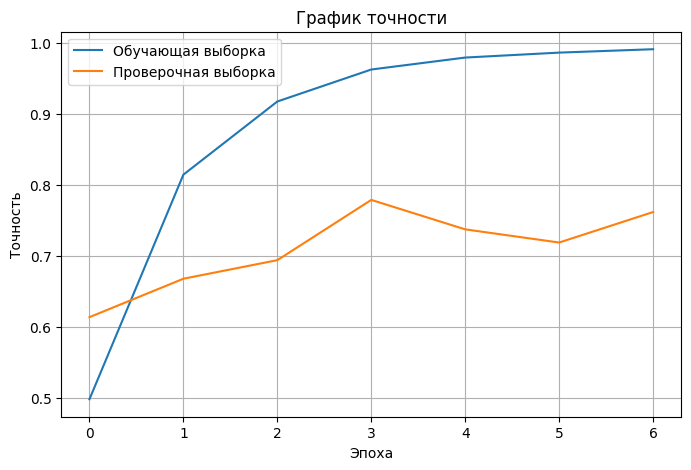

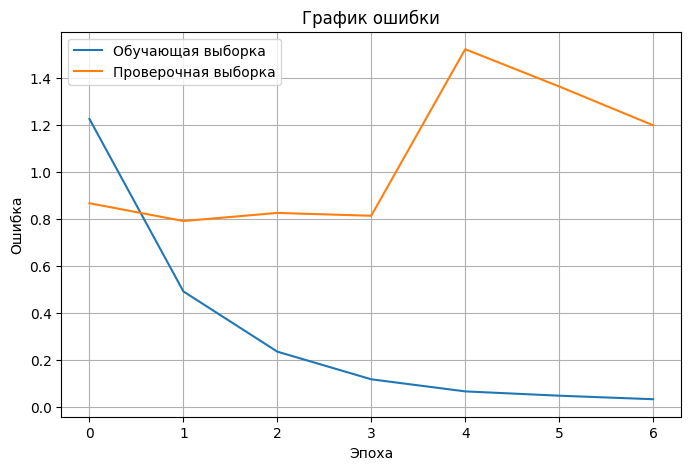

In [ ]:
VOCAB_SIZE = 10000
WIN_SIZE = 1000
WIN_HOP = 100

model_3, history_3, best_acc_3 = run_experiment(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

show_graph(history_3)

results_df = add_result(3, VOCAB_SIZE, WIN_SIZE, WIN_HOP, history_3)

x_train: (18417, 1000)
y_train: (18417,)
x_val: (6968, 1000)
y_val: (6968,)
Эпоха 1/30 Ошибка: 1.3213 Точность: 0.4486 Проверка: 0.6233
Эпоха 2/30 Ошибка: 0.5495 Точность: 0.7959 Проверка: 0.7101
Эпоха 3/30 Ошибка: 0.2172 Точность: 0.9253 Проверка: 0.7555
Эпоха 4/30 Ошибка: 0.0977 Точность: 0.9683 Проверка: 0.6979
Эпоха 5/30 Ошибка: 0.0623 Точность: 0.9828 Проверка: 0.6277
Эпоха 6/30 Ошибка: 0.0382 Точность: 0.9891 Проверка: 0.7024
Ранняя остановка


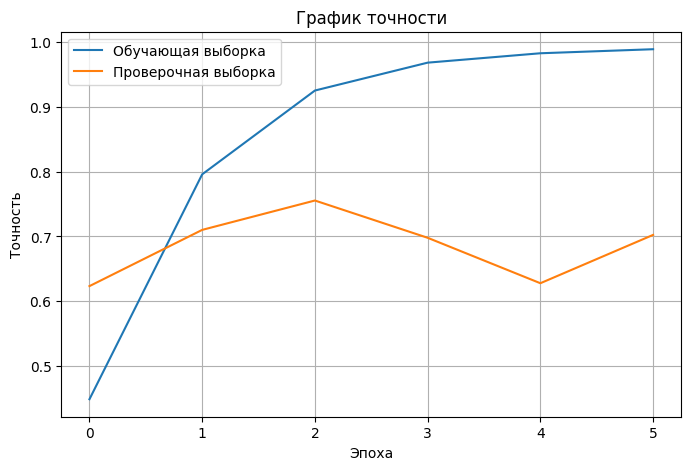

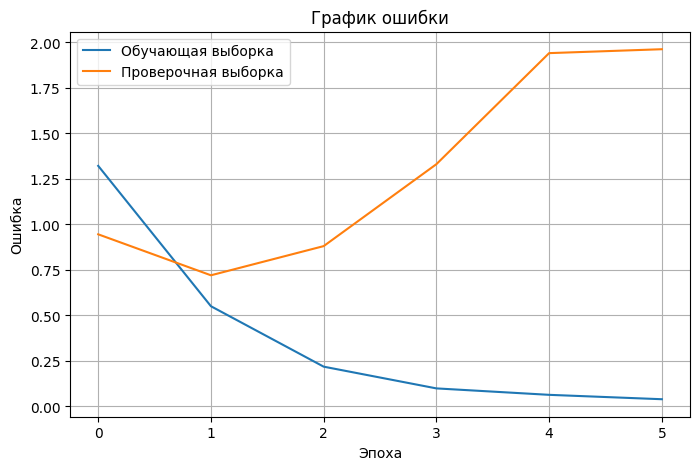

In [ ]:
VOCAB_SIZE = 40000
WIN_SIZE = 1000
WIN_HOP = 100

model_4, history_4, best_acc_4 = run_experiment(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

show_graph(history_4)

results_df = add_result(4, VOCAB_SIZE, WIN_SIZE, WIN_HOP, history_4)

x_train: (36892, 500)
y_train: (36892,)
x_val: (13992, 500)
y_val: (13992,)
Эпоха 1/30 Ошибка: 0.9776 Точность: 0.6143 Проверка: 0.6841
Эпоха 2/30 Ошибка: 0.2662 Точность: 0.9106 Проверка: 0.7098
Эпоха 3/30 Ошибка: 0.1168 Точность: 0.9642 Проверка: 0.6407
Эпоха 4/30 Ошибка: 0.0654 Точность: 0.9815 Проверка: 0.7308
Эпоха 5/30 Ошибка: 0.0422 Точность: 0.9889 Проверка: 0.7248
Эпоха 6/30 Ошибка: 0.0302 Точность: 0.9928 Проверка: 0.6751
Эпоха 7/30 Ошибка: 0.0250 Точность: 0.9942 Проверка: 0.7178
Ранняя остановка


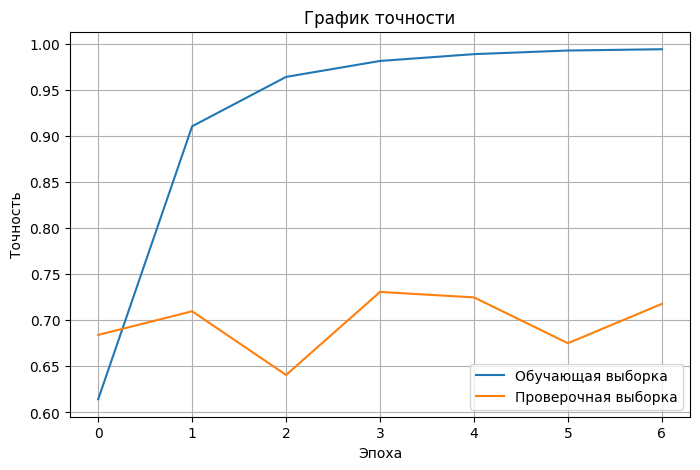

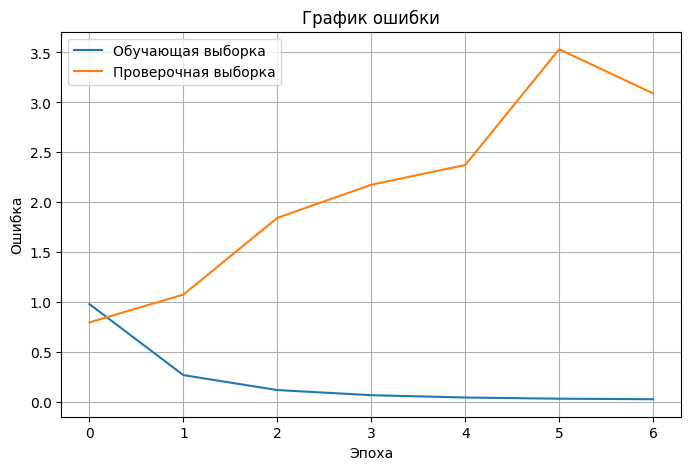

In [ ]:
VOCAB_SIZE = 20000
WIN_SIZE = 500
WIN_HOP = 50

model_5, history_5, best_acc_5 = run_experiment(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

show_graph(history_5)

results_df = add_result(5, VOCAB_SIZE, WIN_SIZE, WIN_HOP, history_5)

x_train: (9180, 2000)
y_train: (9180,)
x_val: (3455, 2000)
y_val: (3455,)
Эпоха 1/30 Ошибка: 1.5327 Точность: 0.3642 Проверка: 0.4234
Эпоха 2/30 Ошибка: 1.0620 Точность: 0.5869 Проверка: 0.5334
Эпоха 3/30 Ошибка: 0.6120 Точность: 0.7839 Проверка: 0.6822
Эпоха 4/30 Ошибка: 0.3660 Точность: 0.8815 Проверка: 0.7019
Эпоха 5/30 Ошибка: 0.2242 Точность: 0.9273 Проверка: 0.7311
Эпоха 6/30 Ошибка: 0.1338 Точность: 0.9598 Проверка: 0.7311
Эпоха 7/30 Ошибка: 0.0901 Точность: 0.9734 Проверка: 0.7673
Эпоха 8/30 Ошибка: 0.0663 Точность: 0.9802 Проверка: 0.7849
Эпоха 9/30 Ошибка: 0.0445 Точность: 0.9874 Проверка: 0.7386
Эпоха 10/30 Ошибка: 0.0468 Точность: 0.9881 Проверка: 0.7705
Эпоха 11/30 Ошибка: 0.0366 Точность: 0.9902 Проверка: 0.7297
Ранняя остановка


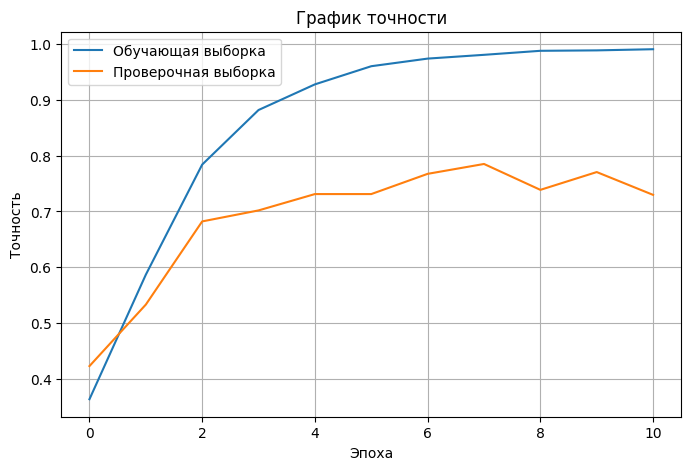

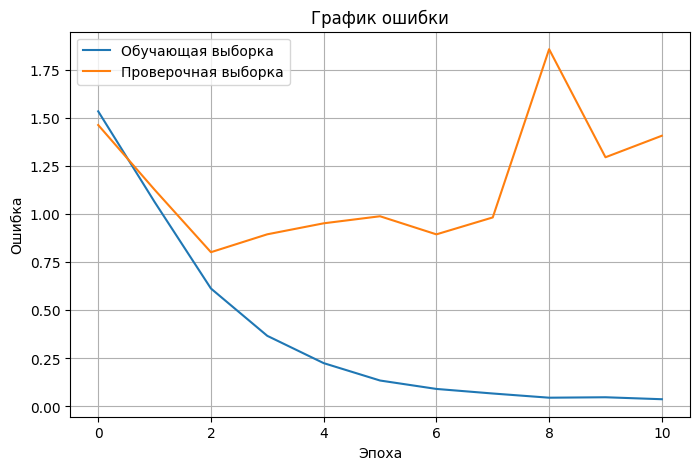

In [ ]:
VOCAB_SIZE = 20000
WIN_SIZE = 2000
WIN_HOP = 200

model_6, history_6, best_acc_6 = run_experiment(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

show_graph(history_6)

results_df = add_result(6, VOCAB_SIZE, WIN_SIZE, WIN_HOP, history_6)

In [ ]:
display(results_df)

,Эксперимент,VOCAB_SIZE,WIN_SIZE,WIN_HOP,Количество эпох,Точность на обучении,Точность на проверке,Лучшая точность на проверке,Ошибка на обучении,Ошибка на проверке,Лучшая ошибка на проверке
0,1,20000,1000,100,9,0.994733,0.710390,0.755023,0.016727,2.738004,0.635902
1,2,5000,1000,100,13,0.997014,0.748134,0.774541,0.013682,2.895401,0.848865
2,3,10000,1000,100,7,0.990769,0.761625,0.778703,0.033326,1.199316,0.791669
3,4,40000,1000,100,6,0.989086,0.702354,0.755454,0.038191,1.962556,0.719597
4,5,20000,500,50,7,0.994226,0.717767,0.730775,0.024983,3.088106,0.794725
5,6,20000,2000,200,11,0.990196,0.729667,0.784949,0.036611,1.405914,0.800705
